Open this notebook in Jupyter or upload it to Colab to run it.

# Text Classification with scikit-learn

In [1]:
# Dependencies for the lab
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

## Overview:
This notebook uses scikit-learn to turn raw 20 Newsgroups posts into TF-IDF features and compare KNN, decision-tree, and logistic-regression classifiers.

The 20 newsgroups dataset comprises around 18000 newsgroups posts on 20 topics. The 20 categories are:
```
['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']
```
The posts are raw text. For example:

**Post:**
```
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----
```

**Target:**
```
'rec.autos'
```

Your task will be to build a classifier to predict the category of posts. You will do the following in this notebook:

## Exercise 1: Retrieve the Data
Download `fetch_20newsgroups` dataset

In [2]:
from sklearn.datasets import fetch_20newsgroups
data = fetch_20newsgroups()
docs = data['data']
targets = data["target"]
names = data.target_names

Print off the first document and its target classification to make sure its been downloaded correctly 

In [3]:
print(docs[0], names[targets[0]])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----




 rec.autos


## Exercise 2: Understand the Data

Perform some exploratory analysis on your data. Specifically, plot a bar chart showing distribution of the categories (classes)

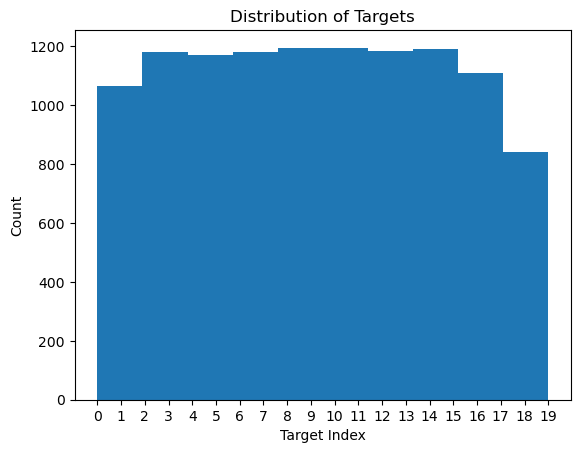

In [4]:
np.unique(targets)
plt.hist(x=targets)
plt.xticks(range(0,20))
plt.xlabel("Target Index")
plt.ylabel("Count")
plt.title("Distribution of Targets")
plt.show()

## Exercise 3: Engineer the Data
Extract features from raw text. You are free to be creative here. There is no correct answer. Try and think of the features (input) that are most predictive of the category. Some helpful sklearn feature engineering code can be found here (I'd recommend reading through the documentation before diving in and trying to get these tools to work):

* [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer)
* [TFIDF Text Features](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [5]:
vectorizer = sklearn.feature_extraction.text.CountVectorizer()
X = vectorizer.fit_transform(docs)

In [6]:
tfidf = sklearn.feature_extraction.text.TfidfVectorizer()
X2 = tfidf.fit_transform(docs)

## Exercise 4: Split the Data

Split your data into train and test splits. Use an 80%/20% split rule for train and test respectively. I'd recommend using the function from the last lab

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X2, targets, test_size=0.2, random_state=0)

In [8]:
X_train.shape

(9051, 130107)

In [9]:
X_test.shape

(2263, 130107)

## Exercise 5: Train the Model

Using sklearn, train the following three classifiers using the training set:
* KNN
* Decision Tree
* Logistic Regression

In [10]:
# Train the model using the KNN Cluster Algorithm
from sklearn.neighbors import KNeighborsClassifier

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X = X_train, y = y_train)
knn_prediction = knn.predict(X=X_test)
knn_probabilities = knn.predict_proba(X=X_test)

/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [12]:
# Train the model using the Decision Tree Algorithm
from sklearn.tree import DecisionTreeClassifier

In [13]:
tree = DecisionTreeClassifier(criterion='entropy', max_depth=1000, splitter='best')
tree.fit(X = X_train, y = y_train)
tree_prediction = tree.predict(X=X_test)
tree_probabilities = tree.predict_proba(X=X_test)

In [14]:
# Train the model using the Logistic Regression Algorithm
from sklearn.linear_model import LogisticRegression

In [15]:
logit = LogisticRegression(penalty=None, fit_intercept=True, max_iter=1000)
logit.fit(X_train, y_train)
logit_prediction = logit.predict(X=X_test)
logit_probabilites = logit.predict_proba(X=X_test)

## Exercise 6: Evaluate the Model
Compare the performance of your classifiers on the test set. Discuss which one performs the best.

In [16]:
import seaborn as sns

In [17]:
get_accuracy = lambda y_true, y_hat: np.mean(y_true == y_hat)

In [18]:
# Evaluate the KNN Cluster model
print(f"Accuracy of KNN: {get_accuracy(y_test, knn_prediction)}")

Accuracy of KNN: 0.7861246133451171


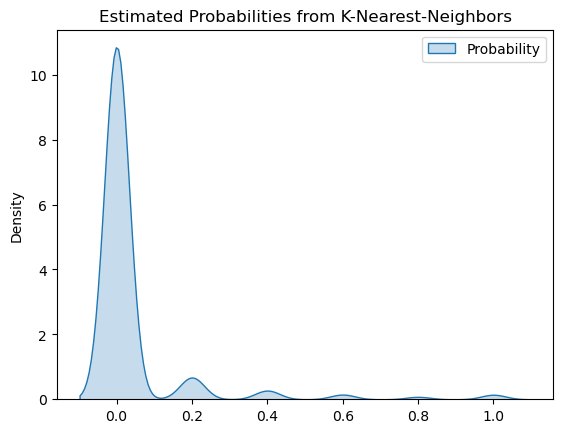

In [19]:
sns.kdeplot(knn_probabilities[:, 1], fill=True, label='Probability')
plt.legend()
plt.title("Estimated Probabilities from K-Nearest-Neighbors")
plt.show()

In [20]:
# Evaluate the Decision Tree model
print(f"Accuracy of Decision Tree: {get_accuracy(y_test, tree_prediction)}")

Accuracy of Decision Tree: 0.46354396818382676


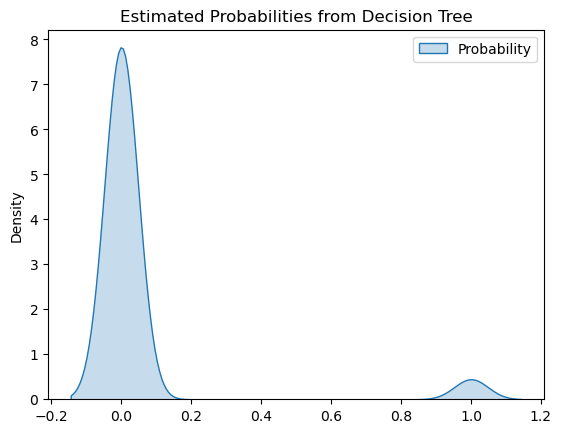

In [21]:
sns.kdeplot(tree_probabilities[:, 1], fill=True, label='Probability')
plt.legend()
plt.title("Estimated Probabilities from Decision Tree")
plt.show()

In [22]:
# Evaluate the Logistic Regression model
print(f"Accuracy of Logistic Regression: {get_accuracy(y_test, logit_prediction)}")

Accuracy of Logistic Regression: 0.8992487847989394


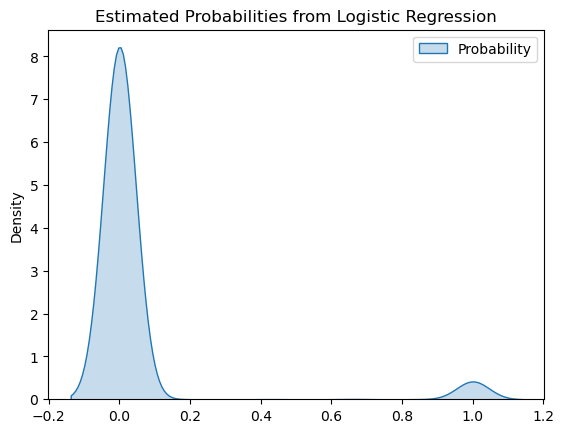

In [23]:
sns.kdeplot(logit_probabilites[:, 1], fill=True, label='Probability')
plt.legend()
plt.title("Estimated Probabilities from Logistic Regression")
plt.show()

Discuss which one performs the best:

>**Logistic regression performed the best in the recorded run**, with an accuracy of about 0.90. This is a 20-class problem, so its probability estimates are distributions across all 20 classes rather than binary 0/1 values.

>**KNN came in second** in the recorded run, with an accuracy of about 0.79. Its probability estimates are also multiclass distributions.

>**The decision tree came in last** in the recorded run, with an accuracy of about 0.46. A single unconstrained tree can struggle with the high-dimensional, sparse vocabulary representation. Results may change if the split, preprocessing, or model settings change.